In [117]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns

# caused error for modifying a copy of original dataframe
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)


# Assign the data into a dataframe

df = pd.read_csv(r'C:\Users\visio\Desktop\Correlation Project\movies.csv')


In [119]:
# Let's look at the data

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [121]:
# Let's see if there's any missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

# There are some missing data, so remove every row with missing data:
# I do not like modifying the original one, so assign it to a new dataframe
cdf = df.dropna()

print('-'*100)

# See if there still are any missing data:
for col in cdf.columns:
    pct_missing = np.mean(cdf[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

# now we need to use cdf, a new dataframe

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%
----------------------------------------------------------------------------------------------------
name - 0.0%
rating - 0.0%
genre - 0.0%
year - 0.0%
released - 0.0%
score - 0.0%
votes - 0.0%
director - 0.0%
writer - 0.0%
star - 0.0%
country - 0.0%
budget - 0.0%
gross - 0.0%
company - 0.0%
runtime - 0.0%


In [123]:
# Check data types for our columns

cdf.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [125]:
# Change datatype of columns

cdf['budget'] = cdf['budget'].astype('int64')

cdf['gross'] = cdf['gross'].astype('int64')

# Extra cuz original dataset has been changed
cdf['votes'] = cdf['votes'].astype('int64')

cdf['runtime'] = cdf['runtime'].astype('int64')

In [127]:
# Create correct year column

cdf['yearcorrect'] = cdf['released'].str.extract(pat = '([0-9]{4})').astype(int)

In [53]:
# Sort dataframe with highest to lowest of gross

cdf = cdf.sort_values(by=['gross'], inplace=False, ascending=False)

In [129]:
# Remove the limit of the number of rows showing when we call the dataframe

pd.set_option('display.max_rows', None)

In [137]:
# Drop any duplicates

# df['company'].drop_duplicates().sort_values(ascending=False) --- result is too long

# dataframe.drop_duplicates() = will drop any duplicates inside that dataframe (ex. there are two thefyzz)

In [ ]:
# Assumption 1: budget has high correlation to gross
# Assumption 2: company high correlation to gross

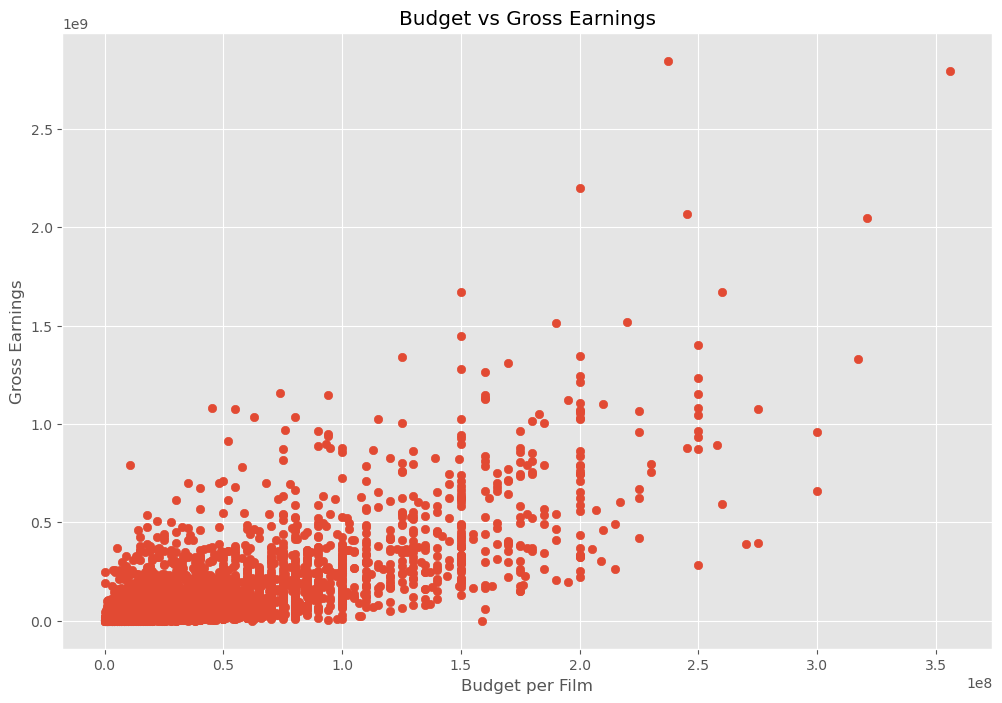

In [133]:
# Scatterplot with budget vs gross

plt.scatter(x=cdf['budget'], y=cdf['gross'])

plt.title('Budget vs Gross Earnings')

plt.ylabel('Gross Earnings')

plt.xlabel('Budget per Film')

plt.show()

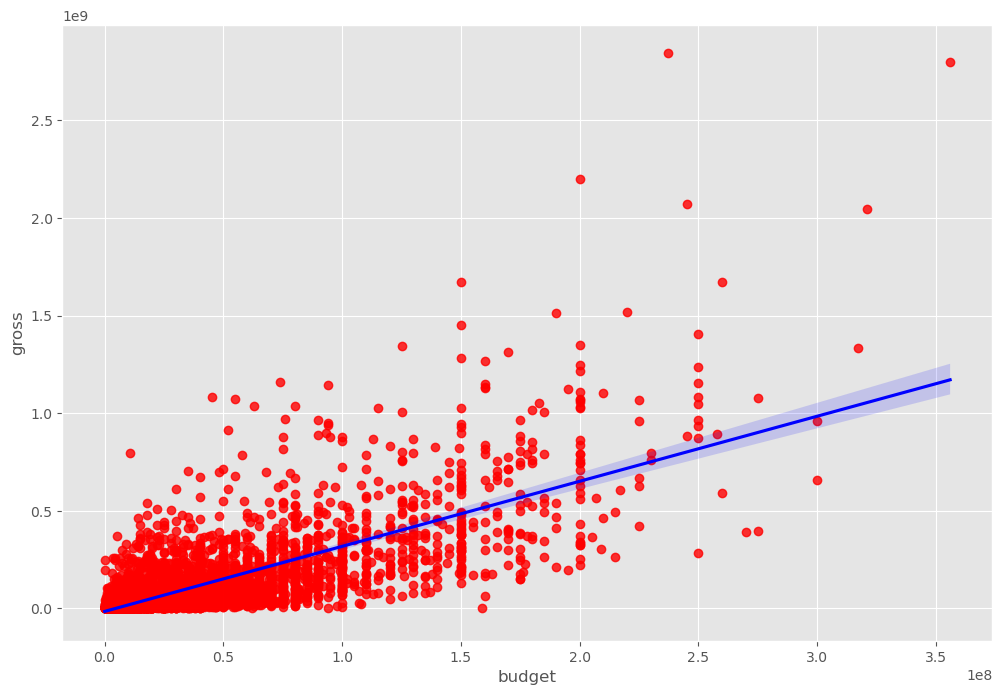

In [135]:
# Plot budget vs gross thru seaborn

sns.regplot(x='budget', y='gross', data=cdf, scatter_kws={"color": "red"}, line_kws={"color": "blue"})
plt.show()

In [139]:
# Looking at correlation
# pearson, kendall, spearman all will display different correlation

# will pose error without this, since a lot of fields are not numerical fields
cdf_numeric = cdf.select_dtypes(include=['number'])

# change method as you want
cdf_numeric.corr(method='pearson')

# High correlation between budget and gross = probably right (0.74...)

,year,score,votes,budget,gross,runtime,yearcorrect
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077,0.998726
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068,0.061923
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303,0.203098
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695,0.320312
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796,0.268721
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000,0.075294
yearcorrect,0.998726,0.061923,0.203098,0.320312,0.268721,0.075294,1.000000


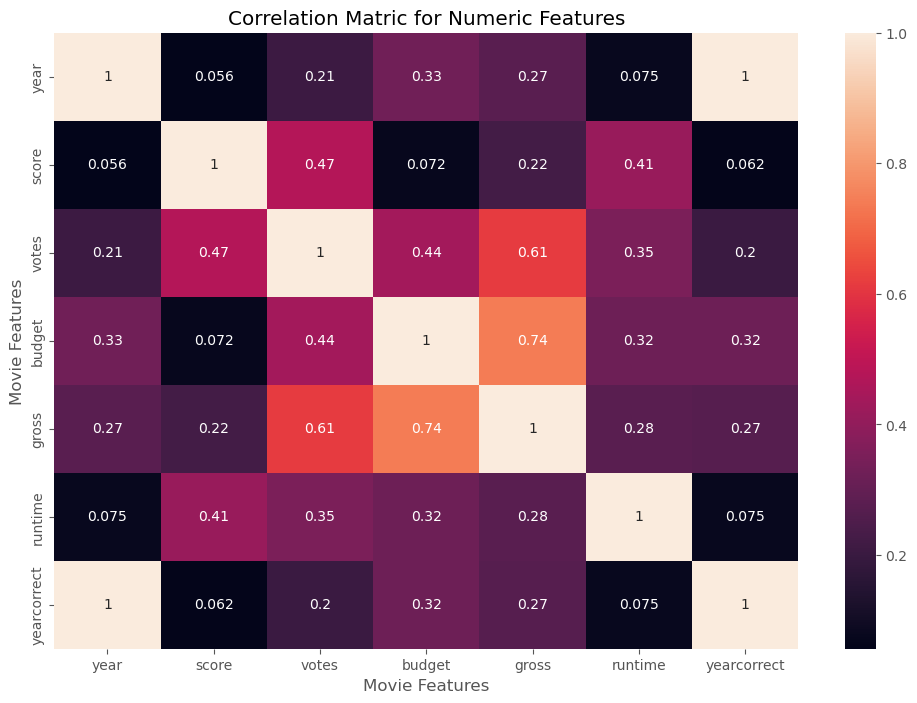

In [141]:
# Heatmap Correlation Visualization 

correlation_matrix = cdf_numeric.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Matric for Numeric Features')

plt.xlabel('Movie Features')

plt.ylabel('Movie Features')

plt.show()

In [143]:
# Looks at correlation with company and other extra features

# Change column type, since some columns are NOT numerical data type
cdf_numerized = cdf

for col_name in cdf_numerized.columns:
    if (cdf_numerized[col_name].dtype == 'object'):
        # if data type of that column is object, change it to 'category' type
        cdf_numerized[col_name] = cdf_numerized[col_name].astype('category')
        # changing data to unique 'codes' of that name (ex. company name 162 = Disney...)
        cdf_numerized[col_name] = cdf_numerized[col_name].cat.codes 

# cdf_numerized

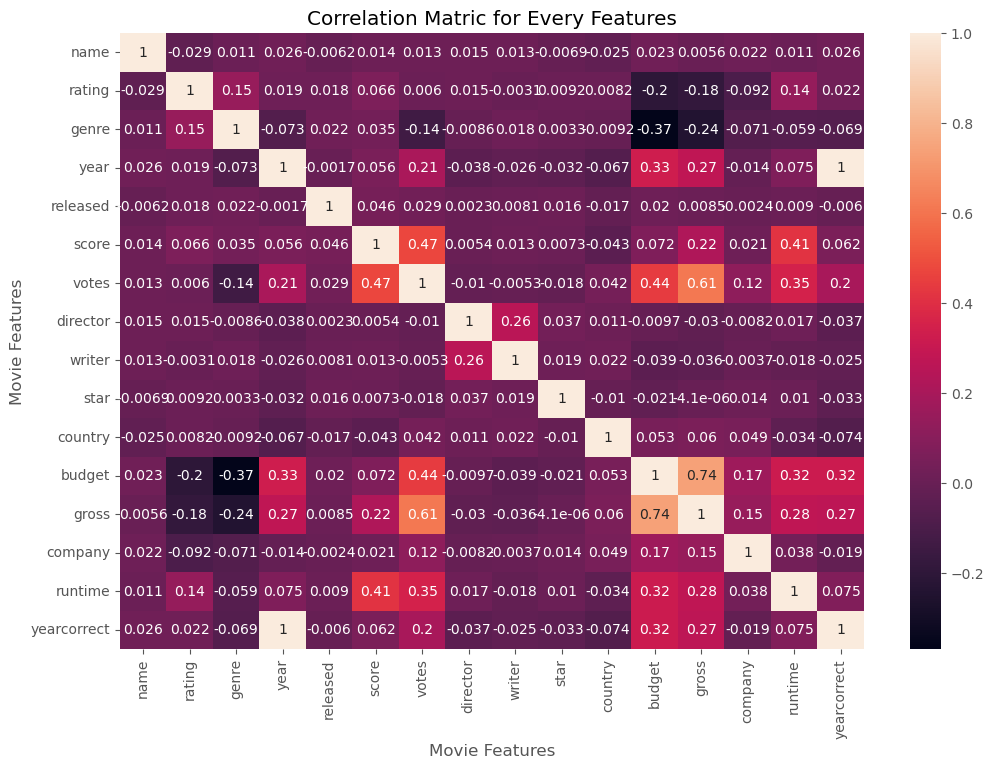

In [145]:
# Heatmap Correlation Matrix, again with all of features

correlation_matrix = cdf_numerized.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Matric for Every Features')

plt.xlabel('Movie Features')

plt.ylabel('Movie Features')

plt.show()

In [147]:
# Lets visualize it better to comprehend correlations easier

correlation_mat = cdf_numerized.corr()

# unstack(): showing correlation as a 'list' type
corr_pairs = correlation_mat.unstack()

# sort_values(): literally sort from lowest correlation --> highest correlation
sorted_pairs = corr_pairs.sort_values()

# show the ones with the higehst correlation (corr > 0.5)
high_corr = sorted_pairs[(sorted_pairs) > 0.5]

high_corr


gross        votes          0.614751
votes        gross          0.614751
gross        budget         0.740247
budget       gross          0.740247
year         yearcorrect    0.998726
yearcorrect  year           0.998726
name         name           1.000000
company      company        1.000000
gross        gross          1.000000
budget       budget         1.000000
country      country        1.000000
star         star           1.000000
writer       writer         1.000000
director     director       1.000000
votes        votes          1.000000
score        score          1.000000
released     released       1.000000
year         year           1.000000
genre        genre          1.000000
rating       rating         1.000000
runtime      runtime        1.000000
yearcorrect  yearcorrect    1.000000
dtype: float64

In [ ]:
### RESULT

# Features that had highest correlation with Gross Revenue of a movie:
# Votes gained (0.61)
# Budget spent (0.74)

# Features that unexpectedly had lower correlation with Gross Revenue of a movie:
# Company directed (0.15)